In [2]:
import os
import random
import numpy as np
import torch #深度学习框架
import torch.nn as nn #neuron network
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision #数据集与图像变换
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def set_seed(seed=42):#固定随机种子让结果可以复现
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("设备：",device)

设备： cuda


In [3]:
#hyper parameters集中便于修改
DATA_ROOT="./data"
BATCH_SIZE=128
NUM_WORKERS=2
NUM_EPOCHS=120
LR=0.1
WEIGHT_DECAY=5e-4 #L2正则化项，避免参数太大导致训练爆炸

In [4]:
#数据预处理与dataloader部分
# CIFAR-10 常用的均值和标准差
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

train_transform=transforms.Compose([
    transforms.RandomCrop(32,padding=4),#先给图片四周加4个像素空白边，再随机裁回32X32，类似让图片轻微平移，平移增广
    transforms.RandomHorizontalFlip(),#随机左右镜像翻转图片，水平方向数据增广
    transforms.ToTensor(),#把取出的图片转为0-1之间浮点张量，通道前置
    transforms.Normalize(CIFAR_MEAN,CIFAR_STD),#对每个颜色通道做标准化，像素值=（像素值-均值）/标准差，Normalization
])

test_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN,CIFAR_STD),#使用相同计算方法来做归一化
])

#download=True 在Colab上会自动下载数据集
train_set=torchvision.datasets.CIFAR10(
    root=DATA_ROOT,train=True,download=True,transform=train_transform
)
test_set=torchvision.datasets.CIFAR10(
    root=DATA_ROOT,train=False,download=True,transform=test_transform
)

#DataLoader按batch取数据，训练集shuffle=True打乱顺序
train_loader=DataLoader(
    train_set,batch_size=BATCH_SIZE,shuffle=True,#用什么训练数据集，每批次处理多少，用多少子进程加载数据加快速度，使用时gpu开启则让数据从cpu传到gpu的速度更快
    num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available()
)
test_loader=DataLoader(
    test_set,batch_size=BATCH_SIZE,shuffle=False,
    num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available()
)

classes = (#int->string 后面映射方便看
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)
print("训练集样本数:", len(train_set), "测试集样本数:", len(test_set))

100%|██████████| 170M/170M [00:05<00:00, 29.6MB/s]


训练集样本数: 50000 测试集样本数: 10000


In [5]:
#卷积神经网络结构
class CIFAR_CNN(nn.Module):#继承自pytorch定义模型的基类
    """
    - 适合32*32彩色图的CNN
    - 卷积+BatchNorm+ReLU：提取特征稳定训练
    - MaxPool：缩小空间尺寸减少计算量
    - AdaptiveAvgPool2d(1)：把特征图变1*1接全连接做十分类
    """
    def __init__(self,num_classes=10):
        super().__init__()#父类的初始化
        self.features=nn.Sequential(
            nn.Conv2d(3,128,kernel_size=3,padding=1),#RGB三通道，特征通道128，外围加一圈变34*34，3*3卷积后大小恰好32*32
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),#2*2中保留最大值，输出：[B, 128, 16, 16]
            nn.Dropout2d(0.05),#随机关闭5%的通道数，缓解过拟合

            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.05),

            nn.Conv2d(256,512,kernel_size=3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),#自适应二维平均池化，对每个通道的整个特征图做全局平均，把一整张图压成一个数值
        )
        self.classifier=nn.Linear(512,num_classes)#分类头，把特征全部转换为10个类别

    def forward(self,x):
        x=self.features(x)
        x=torch.flatten(x,1)#去除维度大小为1的维，[B, 512, 1, 1] -> [B, 512]
        return self.classifier(x)#返回每个样本10个类别上的原始得分logits

model=CIFAR_CNN(num_classes=10).to(device)
criterion=nn.CrossEntropyLoss()#分类任务常用标准交叉熵函数
optimizer=optim.SGD(model.parameters(),lr=LR,momentum=0.9,weight_decay=WEIGHT_DECAY)
#学习率渐变：在综epoch的50%\75%处把lr*0.1便于后期精细收敛
scheduler=optim.lr_scheduler.MultiStepLR(optimizer,milestones=[60,90],gamma=0.1)

In [6]:
#评估函数
@torch.no_grad()#装饰器修饰，全程无梯度
def evaluate(loader):
    '''在loader上算平均loss和accuracy'''
    model.eval()
    total,correct=0,0
    running_loss=0.0
    for images,labels in loader:
        images,labels=images.to(device),labels.to(device)
        logits=model(images)
        loss=criterion(logits,labels)
        running_loss+=loss.item()*images.size(0)#CEloss默认是batch内平均，*batch样本数得到整批loss

        preds=logits.argmax(dim=1) #logits max as the pred type
        correct+=(preds==labels).sum().item()
        total+=labels.size(0)#累加每一轮batch的大小
    return running_loss/total,correct/total

In [7]:
#training cycle
history={
    "train_loss":[],
    "train_acc":[],
    "test_loss":[],
    "test_acc":[],
}

for epoch in range(1,NUM_EPOCHS+1):
    model.train()#打开训练模式
    running_loss,correct,total=0.0,0,0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)

        optimizer.zero_grad(set_to_none=True)#清空上一步梯度
        logits=model(images)
        loss=criterion(logits,labels)
        loss.backward()#反向传播算梯度
        optimizer.step()#根据梯度更新参数

        running_loss+=loss.item()*images.size(0)#total loss
        preds=logits.argmax(dim=1)
        correct+=(preds==labels).sum().item()
        total+=labels.size(0)

    train_loss=running_loss/total
    train_acc=correct/total

    test_loss,test_acc=evaluate(test_loader)

    scheduler.step()#更新lr

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch [{epoch:3d}/{NUM_EPOCHS}]"
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc{test_acc:.4f} | "
        f"LR: {scheduler.get_last_lr()[0]:.6f}"
    )

#report the last epoch result
final_test_loss,final_test_acc=evaluate(test_loader)
print(f"\nFinal-Loss: {final_test_loss:.4f}, Accuracy: {final_test_acc:.4f}")


Epoch [  1/120]Train Loss: 1.5164 | Train Acc: 0.4375 | Test Loss: 1.2198 | Test Acc0.5583 | LR: 0.100000
Epoch [  2/120]Train Loss: 1.0488 | Train Acc: 0.6239 | Test Loss: 0.9713 | Test Acc0.6612 | LR: 0.100000
Epoch [  3/120]Train Loss: 0.8327 | Train Acc: 0.7042 | Test Loss: 0.8154 | Test Acc0.7246 | LR: 0.100000
Epoch [  4/120]Train Loss: 0.7031 | Train Acc: 0.7569 | Test Loss: 0.8411 | Test Acc0.7247 | LR: 0.100000
Epoch [  5/120]Train Loss: 0.6172 | Train Acc: 0.7886 | Test Loss: 0.6986 | Test Acc0.7671 | LR: 0.100000
Epoch [  6/120]Train Loss: 0.5737 | Train Acc: 0.8038 | Test Loss: 0.5880 | Test Acc0.8023 | LR: 0.100000
Epoch [  7/120]Train Loss: 0.5360 | Train Acc: 0.8152 | Test Loss: 0.6123 | Test Acc0.7980 | LR: 0.100000
Epoch [  8/120]Train Loss: 0.5073 | Train Acc: 0.8272 | Test Loss: 0.6111 | Test Acc0.7944 | LR: 0.100000
Epoch [  9/120]Train Loss: 0.4865 | Train Acc: 0.8320 | Test Loss: 0.5471 | Test Acc0.8148 | LR: 0.100000
Epoch [ 10/120]Train Loss: 0.4703 | Train Acc:

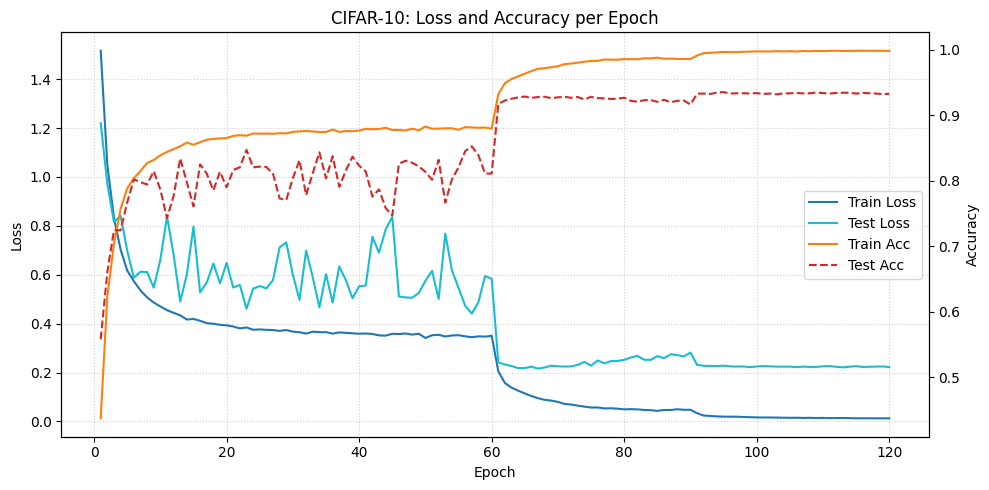

In [8]:
#loss acc figure
epochs=range(1,NUM_EPOCHS+1)

fig,ax1=plt.subplots(figsize=(10,5))

#left: loss
color_loss_train="tab:blue"
color_loss_test="tab:cyan"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss",color="black")
ax1.plot(epochs,history["train_loss"],label="Train Loss",color=color_loss_train)
ax1.plot(epochs,history["test_loss"],label="Test Loss",color=color_loss_test)
ax1.tick_params(axis="y")
ax1.grid(True,linestyle=":",alpha=0.6)

#right: acc
ax2=ax1.twinx()#共用一个x轴
ax2.set_ylabel("Accuracy",color="black")
ax2.plot(epochs,history["train_acc"],label="Train Acc",color="tab:orange")
ax2.plot(epochs,history["test_acc"],label="Test Acc",color="tab:red",linestyle="--")
ax2.tick_params(axis="y")

lines1,labels1=ax1.get_legend_handles_labels()
lines2,labels2=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2,labels1+labels2,loc="center right")

plt.title("CIFAR-10: Loss and Accuracy per Epoch")
plt.tight_layout()
plt.show()

$$
\begin{aligned}
\text{归一化：} &\quad x_{\text{norm}} = \frac{x_{\text{raw}} - \mu}{\sigma} \\
\text{反归一化：} &\quad x_{\text{raw}} = x_{\text{norm}} \cdot \sigma + \mu
\end{aligned}
$$

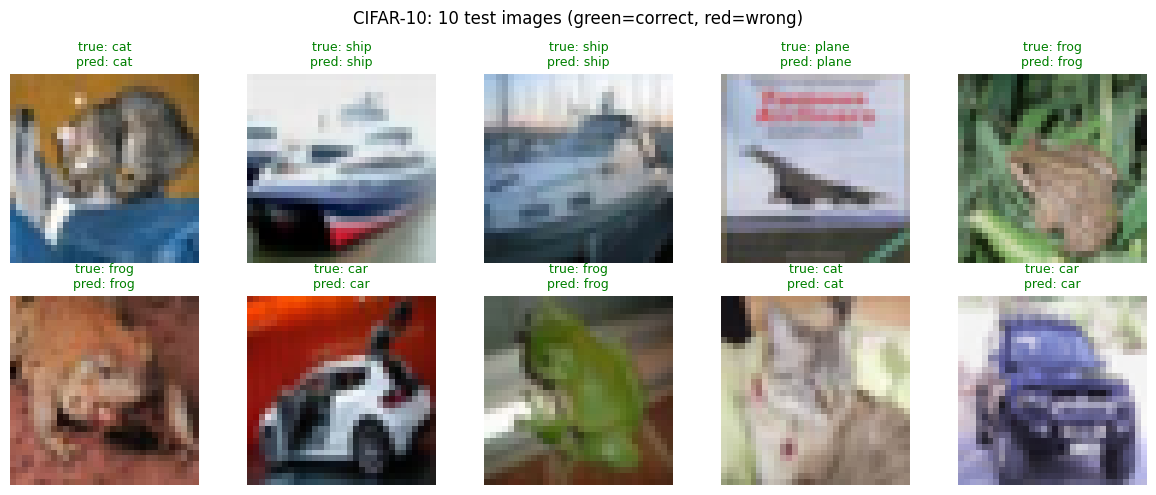

In [9]:
#反归一化，便于matplotlib显示正常颜色，展示测试集中十张图的测试结果
def denormalize(tensor_img):
    mean=torch.tensor(CIFAR_MEAN).view(3,1,1).to(tensor_img.device)
    std=torch.tensor(CIFAR_STD).view(3,1,1).to(tensor_img.device)
    return torch.clamp(tensor_img*std+mean,0,1)#超出0-1的像素截断，避免绘图变色、异常

model.eval()
#从测试集读取一个batch，展示前十
images,labels=next(iter(test_loader))
images,labels=images.to(device),labels.to(device)
with torch.no_grad():
    preds=model(images).argmax(dim=1)

images_cpu=images[:10].cpu()
labels_cpu=labels[:10].cpu()
preds_cpu=preds[:10].cpu()

fig,axes=plt.subplots(2,5,figsize=(12,5))
axes=axes.flatten()
for i in range(10):
    img=denormalize(images_cpu[i]).permute(1,2,0).numpy()
    axes[i].imshow(img)
    axes[i].axis("off")
    true_name=classes[labels_cpu[i]]
    pred_name=classes[preds_cpu[i]]
    color="green" if labels_cpu[i]==preds_cpu[i] else "red"
    axes[i].set_title(f"true: {true_name}\npred: {pred_name}",color=color,fontsize=9)
plt.suptitle("CIFAR-10: 10 test images (green=correct, red=wrong)")
plt.tight_layout()
plt.show()